# **Raport: Lista 1**

## 1. Wybór i opis zbioru danych

1. **`Zbiór: Telco Customer Churn`** pobrany z platformy Kaggle. Klasyczny, bardzo czytelny zbiór podany w "proponowanych zbiorach danych" w liście, spełnia wymogi instrukcji oraz idealnie wpasowuje się w zalecany rozmiar, co pozwala na wiarygodny podział na zbiór treningowy i testowy bez ryzyka przeuczenia "na pamięć". Biznesowy charakter danych (przewidywanie odejścia klienta) sprawia, że tworzenie logicznych reguł decyzyjnych jest intuicyjne.

2. **Opis Zbioru:**
    1. **Zmienna docelowa:**
        *   **Churn** - czy klient zrezygnował z usług w ostatnim miesiącu (`bool`).

    2. **Dane demograficzne klienta:**
        *   **CustomerID** - unikalne ID klienta (`string`).
        *   **Gender** - płeć (`Male / Female- string`).
        *   **SeniorCitizen** - czy klient jest seniorem (`bool`).
        *   **Partner** - czy klient ma partnera (`bool`).
        *   **Dependents** - czy klient ma kogoś na utrzymaniu (`bool`).

    3. **Informacje o koncie i płatnościach:**
        *   **Tenure** - liczba miesięcy klienta w firmie (`int`).
        *   **Contract** - rodzaj zawartej umowy (`string`).
        *   **PaperlessBilling** - czy klient korzysta z faktur elektronicznych (`bool`).
        *   **PaymentMethod** - sposób płatności (`string`).
        *   **MonthlyCharges** - miesięczna kwota abonamentu (`float`).
        *   **TotalCharges** - całkowita kwota zapłacona przez klienta od początku umowy (`float`).

    4. **Posiadane usługi:**
        *   **PhoneService** - czy posiada telefon stacjonarny (`bool`).
        *   **MultipleLines** - czy posiada wiele linii telefonicznych (`string`).
        *   **InternetService** - dostawca internetu (`string`).
        *   **OnlineSecurity** - czy wykupił bezpieczeństwo online (`string`).
        *   **OnlineBackup** - czy posiada kopię zapasową online (`string`).
        *   **DeviceProtection** - czy posiada ubezpieczenie sprzętu (`string`).
        *   **TechSupport** - czy wykupił wsparcie techniczne (`string`).
        *   **StreamingTV / StreamingMovies** - czy korzysta z serwisów streamingowych dostarczanych przez firmę (`string`).

3. **Kluczowe dane w zbiorze:**
    1. **Cechy liczbowe (numeryczne / ciągłe):**
        *   **`MonthlyCharges`**
        *   **`TotalCharges`**
        *   **`tenure`**

    2. **Cechy kategorialne (tekstowe / dyskretne):**
        * **`Contract`**
        * **`OnlineSecurity`**
        * **`InternetService`**
        * **`TechSupport`**
        * **`OnlineBackup`**
        * **`StreamingMovies`**
        * **`StreamingTV`** 
        * **`DeviceProtection`**

In [19]:
# wczytanie bibliotek potrzebnych do analizy danych
import pandas
import matplotlib.pyplot as plt
import seaborn

import sys
sys.path.append('..') # dodanie glownego foldera do projektu

# wczytanie danych i ustawienie precyzji
pandas.set_option("display.precision", 2)
df = pandas.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Przeprowadzenie EDA dla cech numerycznych


In [20]:
df.info()
df.describe(include=["str", "float64", "int64"])

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.00,7043,7043,7043.00,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.00,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.16,NaN,NaN,32.37,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.76,NaN,NaN
std,NaN,NaN,0.37,NaN,NaN,24.56,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.09,NaN,NaN
min,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.25,NaN,NaN
25%,NaN,NaN,0.00,NaN,NaN,9.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.50,NaN,NaN
50%,NaN,NaN,0.00,NaN,NaN,29.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.35,NaN,NaN
75%,NaN,NaN,0.00,NaN,NaN,55.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.85,NaN,NaN


Mając ogólny pogląd na statystyki opisowe, należy znaleść zależności między cechami klientów a zmienną docelową `Churn`. Ponieważ zbiór posiada 20 kolumn opisujących klienta, ślepe generowanie wykresów dla każdej z nich byłoby nieefektywne.


**Analizowane cechy numeryczne o potencjalnie wysokim poziomie decyzyjności:** <br>
Celem jest znalezienie wyraźnych punktów odcięcia (progów), które w kolejnych etapach posłużą do zbudowania logiki ręcznego systemu decyzyjnego. 

**Do analizy wybrano następujące kluczowe zmienne ciągłe:**
* **`MonthlyCharges`** (wrażliwość na cene)
* **`tenure`** (lojalność / staż klienta)
* Zależność między nimi (**`TotalCharges`**)

In [ ]:
import src.utils.utils as utils

# czyszczenie danych i konwersja kolumn
df = df.drop('customerID', axis=1)

utils.map_dtypes_str_to_float(df, 'TotalCharges')

utils.map_dtypes_str_to_bool(df, 'Partner')
utils.map_dtypes_str_to_bool(df, 'Dependents')
utils.map_dtypes_str_to_bool(df, 'PhoneService')
utils.map_dtypes_str_to_bool(df, 'PaperlessBilling')
utils.map_dtypes_str_to_bool(df, 'Churn')

display(df.describe())


ValueError: Unable to parse string " " at position 488

### Wykresy

**Histogram rozkładu opłat miesięcznych względem tego czy klient zrezygnował z usług w ostatnim miesiącu** <br>
Analiza opłat miesięcznych- cena jest jednym z głównych czynników decyzyjnych w każdej usłudze. <br>

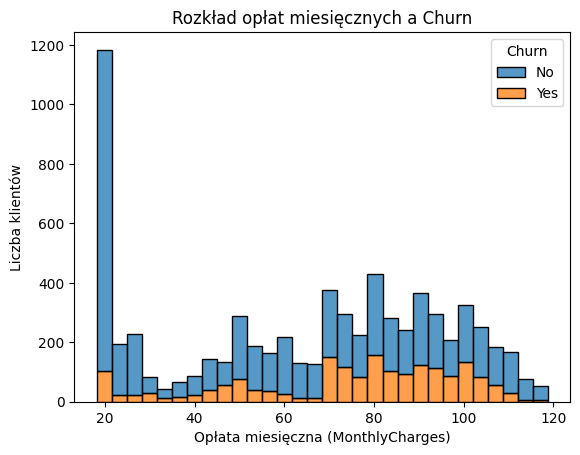

In [ ]:
seaborn.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', bins=30)
plt.title('Rozkład opłat miesięcznych a Churn')
plt.xlabel('Opłata miesięczna (MonthlyCharges)')
plt.ylabel('Liczba klientów')
plt.show()

**Wniosek do modelu:** Z wykresu wyraźnie widać, że w przedziale niskich opłat (20$) klienci prawie wcale nie rezygnują. Natomiast w strefie wysokich opłat (70$ - 110$) proporcja odchodzących rośnie.

**Boxplot dla opłat miesięcznych** <br>
Uzupełnieniem histogramu jest boxplot, który pozwoli precyzyjnie wyznaczyć medianę i sprawdzić, o ile droższe są pakiety osób rezygnujących w porównaniu do lojalnych klientów. Wykres pozwoli zobaczyć ewentualne wartości odstające.

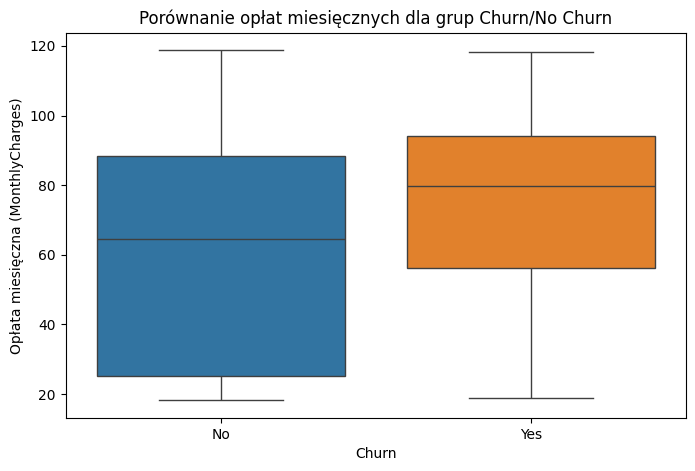

In [ ]:
plt.figure(figsize=(8, 5))
seaborn.boxplot(data=df, x='Churn', hue='Churn', y='MonthlyCharges')
plt.title('Porównanie opłat miesięcznych dla grup Churn/No Churn')
plt.ylabel('Opłata miesięczna (MonthlyCharges)')
plt.show()

**Wniosek do modelu:** Mediana opłat dla klientów odchodzących to aż około 80$, podczas gdy dla klientów pozostających wynosi ona około 65$. Obserwacja potwierdza, że zmienna numeryczna `MonthlyCharges` dobrze separuje obie grupy.

**Histogram: stażu klienta w miesiącach a rezygnacja z usług** <br>
Czas, jaki klient spędził z firmą, jest bezpośrednio związany z jego lojalnością. <br>

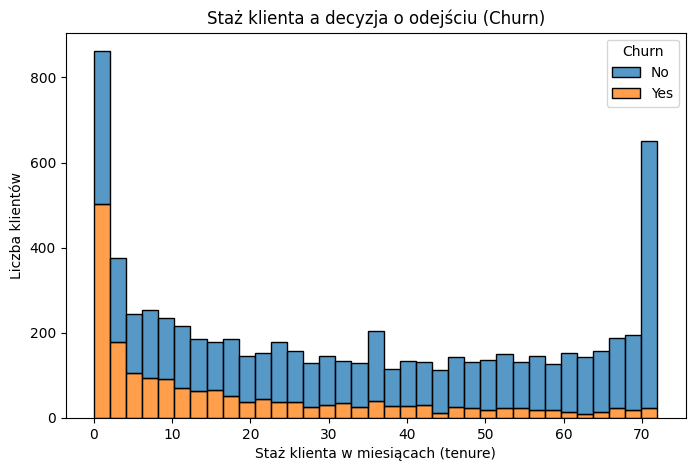

In [ ]:
plt.figure(figsize=(8, 5))
seaborn.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=35)
plt.title('Staż klienta a decyzja o odejściu (Churn)')
plt.xlabel('Staż klienta w miesiącach (tenure)')
plt.ylabel('Liczba klientów')
plt.show()

**Wniosek do modelu:** Największa liczba odejść ma miejsce na samym początku współpracy. Im dłużej klient jest z firmą, tym ryzyko jego odejścia maleje. Użycie w systemie decyzyjnym reguły opierającej się na niskim stażu (np. **tenure < 12**) pozwoli wyłapać dużą część rezygnujących.

**Boxplot dla stażu klienta** <br>
Potwierdzenie obserwacji zaobserwowanych w histogramie- pomoże dobrecyzować wartość do warunku w stystemie <br>

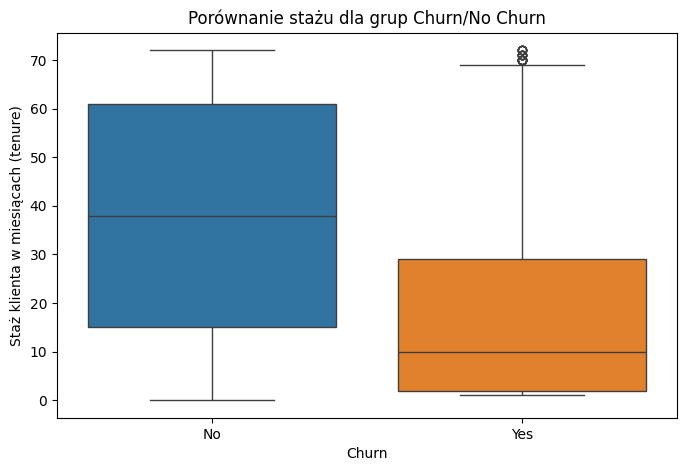

In [ ]:
plt.figure(figsize=(8, 5))
seaborn.boxplot(data=df, x='Churn', hue='Churn', y='tenure')
plt.title('Porównanie stażu dla grup Churn/No Churn')
plt.ylabel('Staż klienta w miesiącach (tenure)')
plt.show()

**Wniosek do modelu:** Mediana stażu dla klientów rezygnujących to zaledwie 10 miesięcy. Z kolei połowa lojalnych klientów jest z firmą dłużej niż 38 miesięcy. Widać dysproporcję, co pozwala wnioskować `tenure` jako jedną z najsilniejszych cech numerycznych zbiorze.

**Scatterplot: zależności między stażem a opłatami miesięcznymi** <br>
Mając dwie kluczowe cechy liczbowe, wykres pozwoli nałożyć je na siebie, aby sprawdzić ich łączyny wpływ <br>

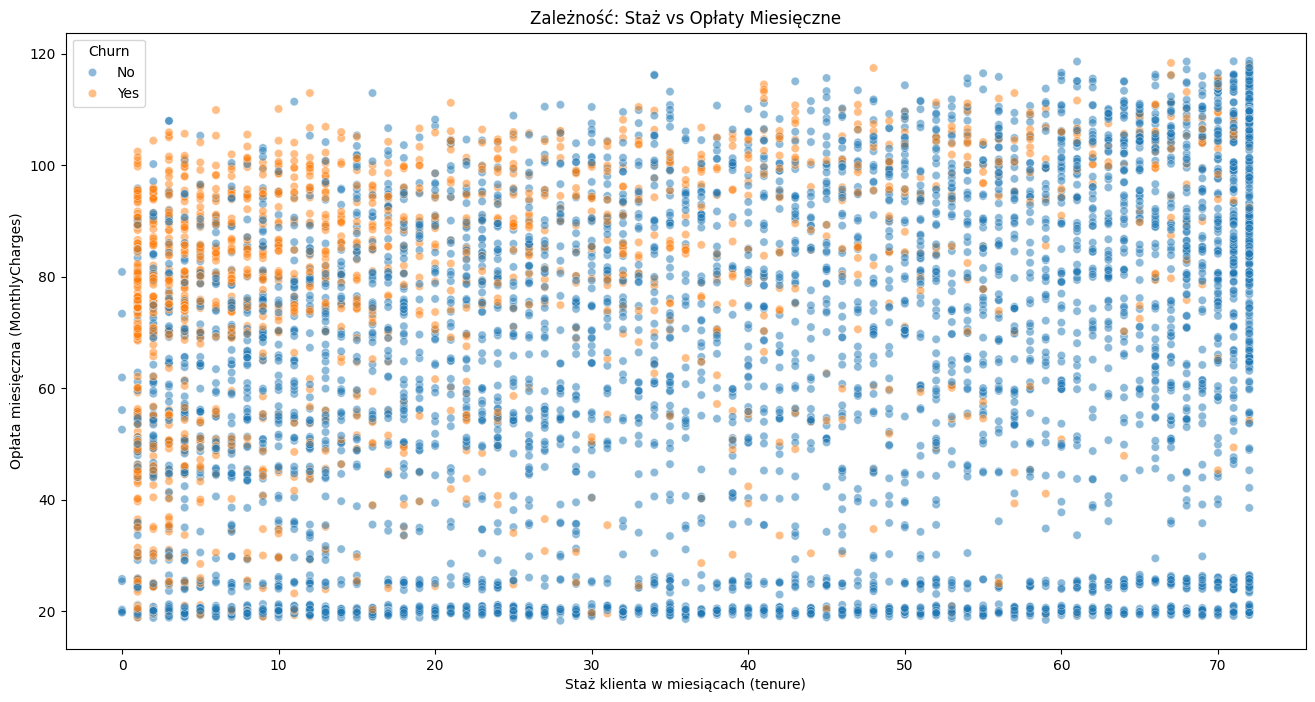

In [ ]:
plt.figure(figsize=(16, 8)) # zwiekszenie rozmiarow wykresu dla czytelnosci

seaborn.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.5)
plt.title('Zależność: Staż vs Opłaty Miesięczne')
plt.xlabel('Staż klienta w miesiącach (tenure)')
plt.ylabel('Opłata miesięczna (MonthlyCharges)')
plt.show()

**Wniosek do modelu:** Wyraźnie widać największe zagęszczenie punktów (Churn=Yes) w lewym górnym rogu. Oznacza to, że idealnym zagnieżdżonym warunkiem logicznym będzie połączenie dwóch wcześniejszych wniosków: `jeśli staż klienta jest krótki oraz jego rachunki są wysokie, przypisz do grupy odchodzącej**.`

## 3. Podstawowe dane dla cech numerycznych

In [ ]:
num_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
display(df[num_columns].describe())

,tenure,MonthlyCharges
count,7043.00,7043.00
mean,32.37,64.76
std,24.56,30.09
min,0.00,18.25
25%,9.00,35.50
50%,29.00,70.35
75%,55.00,89.85
max,72.00,118.75


## 4. Mapowanie dla wieloklasowych cech danych kategorialnych i podział danych

In [ ]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2

# oddzielenie zmeinnych objasniajacych od docelowej
x = df.drop('Churn', axis=1)
y = df['Churn']

# podzial danych
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=TEST_SIZE, random_state=42) # random_state = 42 daje powtarzalność wylosowanych danych

# polaczenie x_train i y_train dla analizy EDA danych kategorialnych- pozwala pokazac analiza cech od Churn tylko dla danych treningowych
train_data = x_train.copy()
train_data['Churn'] = y_train

print(f"Rozmiar całego zbioru: {df.shape[0]}")
print(f"Rozmiar zbioru treningowego: {train_data.shape[0]}")
print(f"Rozmiar zbioru testowego: {x_test.shape[0]}")

Rozmiar całego zbioru: 7043
Rozmiar zbioru treningowego: 5634
Rozmiar zbioru testowego: 1409


## 5. EDA dla danych kategorialnych

In [ ]:
CATEGORIAL_ATTRIBUTES = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

res = {}
for col in CATEGORIAL_ATTRIBUTES:
	# grupowanie po kolumnie i obliczenie średnią z Churn
	churn_rate = train_data.groupby(col)['Churn'].mean() * 100
	
	# obliczenie roznicy miedzy min a max - miara mocy
	diff = churn_rate.max() - churn_rate.min()
	res[col] = diff

# posortowanie cechy od najważniejszej do najmniej ważnej
res_sorted = sorted(res.items(), key=lambda item: item[1], reverse=True)

# wyswietlenie wynikow
print('\n----- Posortowana analiza cechy kategorialnych -----\n')
for attribute, force in res_sorted:
	print(f"{attribute} | Różnica w Churn Rate: {force:.2f} p.p.")

### Wybór 5 najciekawszych danych kategorialnych

Na podstawie analziy EDA wybrano 5 cech, które wskazują **najwiekszą różnicę we wskaźniku rezygnacji (Churn rate)** pomiędzy swoimi kategoriami. Duża dysproporcja świadczy o tym, że dana cecha silnie oddziałuje na decyzję klienta o odejściu.
* **`Contract`** (Rodzaj umowy) - kluczowy wskaźnik lojalności.
* **`OnlineSecurity`**- frustracja klienta.
* **`InternetService`**- główny produkt.
* **`TechSupport`**- frustracja klienta.
* **`OnlineBackup`**- wygoda klienta.

### Wykresy dla 5 wybranych danych kategorialnych

In [ ]:
attributes_choosen = ['Contract', 'OnlineSecurity', 'InternetService', 'TechSupport', 'OnlineBackup']

for i, attribute in enumerate(attributes_choosen, 1):
	plt.figure(figsize=(10,10)) # ustawienie rozmiaru wykresu
	plt.subplot(3, 2, i)
	seaborn.countplot(data=train_data, x=attribute, hue='Churn')
	plt.ylabel('Liczba')
	plt.title(f'Wpływ cechy: {attribute} na Churn')
	plt.show()


**Wnioski do modelu:**

* `Contract:` Wykres potwierdza, że klienci z krótkoterminową umową z miesiąca na miesiąc (`Month-to-month`) stanowią większość odchodzących. To gotowy, najsilniejszy możliwy warunek dla modelu.

* `OnlineSecurity:` Klienci, którzy nie mają wykupionej usługi bezpieczeństwa (`No`), rezygnują częściej. Grupa klientów z tą usługą jest znacznie bardziej stabilna. Warunek sprawdzający, czy klient nie posiada usługi `OnlineSecurity`, będzie sposobem na wyizolowanie grupy zwiększonego ryzyka.

* `InternetService:` Klienci z najnowocześniejszą technologią (`Fiber optic`) – rezygnują najczęściej. Klienci z DSL są znacznie bardziej lojalni. Prawdopodobnie wiąże się to z wyższymi kosztami (`MonthlyCharges`) światłowodu, co potwierdza wcześniejsze wnioski z analizy cech numerycznych. Sprawdzenie, czy klient ma internet światłowodowy, może być użyte w złożonej regule razem z wysokimi opłatami miesięcznymi.

* `TechSupport:` Analogicznie do `OnlineSecurity`. Klienci pozostawieni bez wsparcia technicznego (`No`) są bardziej skłonni do rezygnacji, prawdopodobnie z powodu frustracji nierozwiązanymi problemami.

* `OnlineBackup:` Klienci bez usługi backupu (`No`) stanowią znaczną część grupy rezygnującej. Brak backupu może być wykorzystany w modelu jako wskaźnik ryzyka.

### Mapowanie wieloklasowych cech danych kategorialnych

In [ ]:
columns_to_encode = [
	'gender',
	'MultipleLines', 
	'InternetService', 
	'OnlineSecurity', 
	'OnlineBackup',
	'DeviceProtection', 
	'TechSupport', 
	'StreamingTV', 
	'StreamingMovies',
	'Contract', 
	'PaymentMethod'
]

x_train, x_test = utils.apply_one_hot_encoding(x_train, x_test, columns_to_encode)

print("Kształt zbioru treningowego po zampowaniu One-Hot:", x_train.shape)
print("Kształt zbioru testowego po zampowaniu One-Hot:", x_test.shape)
print("\nFragment zbioru treningowego z nowymi kolumnami:")
display(x_train.head())

## 6. Prosty, jednowarunkowy model decyzyjny

Na podstawie analizy EDA, pierwszą regułą systemu decyzyjnego będzie zmienną **`tenure`** (staż klienta). Jak pokazały wcześniejsze wykresy (szczególnie boxplot), klienci odchodzący mają drastycznie niższy staż niż klienci lojalni. 

Aby wyznaczyć optymalny próg odcięcia, zaimplementowano własny mechanizm automatycznego przeszukiwania (*Grid Search*). Algorytm ten iteruje przez wszystkie możliwe miesiące stażu (od 1 do 72) na **zbiorze treningowym** i wybiera taki próg, który daje najwyższą dokładność.

In [ ]:
import src.models.model_one_condition as model_one_condition
from sklearn.metrics import accuracy_score

# wyznaczenie progu
best_threshold: int = model_one_condition.grid_search(x_train['tenure'], y_train, 1, 72)

print(f'Wyznaczony optymalny próg odcięcia na zbiorze treningowym: {best_threshold}\n')

y_pred_test: pandas.DataFrame = x_test['tenure'].apply(lambda x: model_one_condition.predict(tenure=x, threshold=best_threshold))
model_accuracy : float = accuracy_score(y_test, y_pred_test)

print('\n---- Wynik modelu: ----')
print(f'Dokładność na zbiorze testowym: {(model_accuracy * 100):.2f}%')

## 7. Rozbudowany model decyzyjny

Na podstawie analizy EDA, system został rozbudowany do bardziej złożonego modelu, opierając się na liście najsilniejszych cech:
*   Kategorialne: `Contract`, `OnlineSecurity`, `InternetService`, `TechSupport`, `OnlineBackup`.
*   Numeryczne: `MonthlyCharges`, `tenure`.

**Logika modelu:**
1.  **`Contract`:** Model na samym początku sprawdza, czy klient posiada umowę długoterminową (`One year` lub `Two year`). Zgodnie z analizą, jest to najsilniejszy pojedynczy wskaźnik lojalności. Jeśli warunek jest spełniony, klient jest od razu klasyfikowany jako "pozostający" (0), a dalsza analiza jest przerywana.

2.  **`tenure` i `MonthlyCharges`:** Dla klientów z umową miesięczną, model sprawdza, czy staż jest bardzo krótki (<= 10 miesięcy) oraz czy opłaty są wysokie (> 70$). Ta reguła celuje w najbardziej ryzykowną grupę zidentyfikowaną na wykresie punktowym.

3.  **`InternetService` i `tenure`:** Warunek wyłapuje klientów z usługą internetu (`Fiber optic`), którzy nie są jeszcze długo w firmie (<= 20 miesięcy).

4.  **Brak wsparcia i wysokie opłaty:** Sprawdza, czy klient nie posiada żadniej z trzech najbardziej kluczowych usług wsparcia (`TechSupport`, `OnlineSecurity`, `OnlineBackup`) i jednocześnie płaci wysokie rachunki (> 70$).

5.  **Domyślna decyzja:** Jeśli klient posiada umowę miesięczną, ale nie został zakwalifikowany do żadnej z powyższych grup wysokiego ryzyka, model domyślnie zakłada, że na ten moment pozostanie w firmie.

In [ ]:
import src.models.model_extended as model_extended

y_pred_extended: pandas.DataFrame = x_test.apply(lambda row: model_extended.predict_extended(row), axis=1)
model_accuracy_extended: float = accuracy_score(y_test, y_pred_extended)

print('\n---- Wynik modelu: ----')
print(f"Dokładność na zbiorze testowym: {(model_accuracy_extended * 100):.2f}%")

## 8. Problem regresji

Problem regresji został oparty o ten sam zbiór danych. Celem budowanego modelu będzie przewidywanie **dokładnej kwoty miesięcznego rachunku klienta** (`MonthlyCharges`) na podstawie wybranych przez niego usług.

Na potrzeby tego problemu usunięto ze zmiennych objaśniających:
*   `Churn` (poprzedni cel, tutaj niepotrzebny)
*   `TotalCharges` (jest to bezpośrednia pochodna opłaty miesięcznej i stażu)

### Przygotowanie danych

In [ ]:
import src.models.model_regression as model_reg
TEST_SIZE = 0.2

# podzial danych

y_reg = df['MonthlyCharges']
x_reg = df.drop(['Churn', 'MonthlyCharges', 'TotalCharges'], axis=1)

x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size=TEST_SIZE, random_state=42)

# zastosowanie one-hot encoding dla nowych zbiorow

x_train_reg, x_test_reg = utils.apply_one_hot_encoding(x_train_reg, x_test_reg, columns_to_encode)

### Analiza EDA dla cech usług

Należy ocenić, które cechy kategorialne mają największy wpływ na zmienną docelową- `MonthlyCharges`. W tym celu, na **zbiorze treningowym**, obliczono średnią wysokość rachunku dla każdej kategorii w ramach poszczególnych usług. Pozwoli to wybrać te cechy, które powodują największe skoki cenowe.

In [ ]:
attributes_service = [
  'PhoneService', 
  'MultipleLines', 
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies'
  ]

# uzycie ramki (bez zmapowania kategoralnych cech) do analizy eda
train_data['MonthlyCharges'] = y_train_reg
chagres_attributes_diff = {}

for service in attributes_service:
  mean_charge = train_data.groupby(service)['MonthlyCharges'].mean()
  mean_diff = mean_charge.max() - mean_charge.min()
  chagres_attributes_diff[service] = mean_diff.round(2)
  
# posortowanie cech po najwiekszej roznicy miedzy oplata
chagres_attributes_diff = sorted(chagres_attributes_diff.items(), key=lambda item: item[1], reverse=True)

print('---- Różnica opłat miesięcznych dla każdej kategori usług ----')
for service, charge_diff in chagres_attributes_diff:
  print(f'{service}: {charge_diff}')

### Model Regresji

Na podstawie analizy EDA system regresyjny bazuje na 4 kluczowych cechach kategorialnych, które najsilniej determinują wysokość miesięcznego rachunku (`MonthlyCharges`):
* `InternetService` (główna oś cenowa),
* `StreamingMovies`, `StreamingTV`, `DeviceProtection` (najdroższe usługi dodatkowe).

**Logika:**
Model zlicza, ile płatnych dodatków (z wybranych trzech) posiada klient, a następnie na podstawie rodzaju internetu przypisuje go do jednego z **6 logicznych pakietów cenowych**:
1. **Brak internetu:** Klienci posiadający wyłącznie linię telefoniczną (najtańsza grupa).
2. **Światłowód Premium:** Klienci z `Fiber optic`, którzy wykupili wszystkie 3 analizowane dodatki.
3. **Światłowód Standard:** Klienci ze światłowodem i 1 lub 2 dodatkami.
4. **Światłowód Basic:** Światłowód bez żadnych z analizowanych dodatków.
5. **DSL z dodatkami:** Klienci z internetem DSL, posiadający co najmniej 1 dodatek.
6. **DSL Basic:** Sam internet DSL.

### Obliczenie średnich kosztów dla danego pakietu usług potrzebnego w modelu

In [ ]:
attributes_choosen = ['InternetService', 'StreamingMovies', 'StreamingTV', 'DeviceProtection']

# brak internetu
mean_no_internet = y_train_reg[x_train_reg['InternetService_No'] == 1].mean()

is_fiber = x_train_reg['InternetService_Fiber optic'] == 1
is_dsl = (x_train_reg['InternetService_No'] == 0) & (x_train_reg['InternetService_Fiber optic'] == 0)

has_tv = x_train_reg['StreamingTV_Yes'] == 1
has_movies = x_train_reg['StreamingMovies_Yes'] == 1
has_prot = x_train_reg['DeviceProtection_Yes'] == 1

# obliczenie ile dodatkow
addons_count = has_tv.astype(int) + has_movies.astype(int) + has_prot.astype(int)

# 2. swiatlowod + 3 dodatki
mean_fiber_premium = y_train_reg[is_fiber & (addons_count == 3)].mean()

# 3 swiatlowod + 1 lub 2 dodatki
mean_fiber_standard = y_train_reg[is_fiber & (addons_count > 0) & (addons_count < 3)].mean()

# 4 swiatlowod + 0 dodatkow
mean_fiber_basic = y_train_reg[is_fiber & (addons_count == 0)].mean()

# 5 dsl + 1 < dodatkow
mean_dsl_extras = y_train_reg[is_dsl & (addons_count > 0)].mean()

# 6 dsl + 0 dodatkow
mean_dsl_basic = y_train_reg[is_dsl & (addons_count == 0)].mean()


model_reg_means = model_reg.prepare_calculated_means(
    mean_no_internet, 
    mean_fiber_premium, 
    mean_fiber_standard, 
    mean_fiber_basic, 
    mean_dsl_extras, 
    mean_dsl_basic
) # slownik ze srednimi

print('----Średnie dla cech: ----')
for key, mean in model_reg_means.items():
  print(f'{key}: {mean:.2f}')

### Predykcja modelu

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# predykcja
y_pred_reg = x_test_reg.apply(lambda row: model_reg.predict_regression(row, model_reg_means), axis=1)

# metryki błędów 
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)

print('--- Metryki modelu ---')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')

# wykres
plt.figure(figsize=(10, 6)) # rozmiar
plt.scatter(y_test_reg, y_pred_reg, alpha=0.3, label='Predykcje modelu')
plt.plot([y_test_reg.min(), y_test_reg.max()],[y_test_reg.min(), y_test_reg.max()], color='red', linewidth=2, label='Idealna predykcja') # narysowanie idealnej lini predykcji
plt.title('Regresja: Wartość Rzeczywista vs Predykcja (MonthlyCharges)')
plt.xlabel('Rzeczywista kwota rachunku')
plt.ylabel('Przewidywana kwota rachunku')
plt.legend()
plt.grid(True)
plt.show()

### Wnioski
* **Interpretacja MAE (Mean Absolute Error):** Model przewidując miesięczny rachunek klienta, myli się średnio o zaledwie ok. 6.35$. Biorąc pod uwagę, że rachunki w zbiorze Telco wahają się od 18$ do blisko 119$. Udowadnia to, że wybrane usługi są głównymi czynnikami cenotwórczymi.

* **Interpretacja wykresu:** Przewidywania predykcja nie tworzy ciągłej, ukośnej chmury punktów, lecz układają się w wyraźne poziome pasy.  Funkcja nie estymuje płynnej wartości ciągłej, lecz przypisuje klienta do jednej ze sztywnych kategori, zwracając uśrednioną wartość wyliczoną wcześniej na zbiorze treningowym.

Powyższe wyniki potwierdzają, że za pomocą prostej analizy EDA i agregacji danych można zbudować skuteczny model regresyjny bez użycia zaawansowanych algorytmów uczenia maszynowego.

## 9. Wnioski końcowe

W przypadku analizowanego zbioru (Telco Customer Churn), stworzenie ręcznego systemu decyzyjnego opartego na 5 zagnieżdżonych regułach było zadaniem **łatwym, ale czasochłonnym**. Niewielka liczba cech (ok. 20 kolumn) pozwoliła mi na przeprowadzenie skutecznej i czytelnej analizy EDA. Poprzez wizualizację danych (histogramy, wykresy pudełkowe i punktowe) można było dostrzec zależności, wyznaczyć progi (np. `MonthlyCharges > 70` czy `tenure <= 5`) i przełożyć je na instrukcje warunkowe. Logika biznesowa była przejrzysta, a napisanie kodu dla kilkunastu warunków nie sprawiło trudności technicznych.

Natomiast gdyby zbiór zawierał 1000 lub więcej cech, **ręczne podejście stałoby się ciężkie i bezużyteczne**, z następujących powodów:
1. Wygenerowanie i poprawne zinterpretowanie 1000 wykresów, dostrzeżenie zależności dla jednej osoby byłoby praktycznie nie możliwe
2. W modelu z 20 cechami łatwo było zauważyć zależności np. "Światłowód + Krótki staż". Przy 1000 cech, o rezygnacji mogłaby decydować ukryta zależność między 15 różnymi zmiennymi naraz.
3. Próba napisania reguł obejmujących ułamek z 1000 cech skutkowałaby kodem składającym się z tysięcy linijek zagnieżdżonych instrukcji warunkowych. Taki kod byłby trudny do zrozumienia.
4. Szukanie progów- ręczny algorytm Grid Search dla jednej zmiennej działał błyskawicznie. Przy 1000 zmiennych ciągłych, przeszukiwanie optymalnych progów cięcia metodą "brute-force" zajęłoby znacznie więcej czasu.